# Lab 9 — Text Analysis with TextBlob
<hr style="border: 2px solid black;">

This lab covers the main NLP building blocks provided by **TextBlob**:

| Section | Concept |
|---|---|
| 1 | Setup & installation |
| 2 | Noun phrase extraction |
| 3 | POS tagging |
| 4 | Tokenization |
| 5 | Lemmatization |
| 6 | Sentiment analysis (per review) |
| 7 | Sentiment distribution chart |
| 8 | Polarity score distribution |
| 9 | Word frequency (post-lemmatization) |
| 10 | Word clouds (positive / negative) |
| 11 | Subjectivity vs polarity scatter |

<hr style="border: 2px solid black;">

## Section 1 — Setup & Installation
Run this cell **once** to install all required packages and download NLTK corpora.

In [1]:
%matplotlib inline

# Install packages
!pip install -q textblob wordcloud

# Download NLTK corpora
import nltk
for corpus in ['punkt', 'punkt_tab', 'stopwords',
               'averaged_perceptron_tagger',
               'averaged_perceptron_tagger_eng', 'wordnet']:
    nltk.download(corpus, quiet=True)

!python -m textblob.download_corpora
print("\n✅ Setup complete")


[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.

✅ Setup complete


## Shared Dataset
All sections below use this list of 15 product reviews labelled as
**positive**, **negative** or **neutral**.

In [2]:
reviews_with_sentiment = [
    ("This product is absolutely amazing! I love it so much.",           "positive"),
    ("The features are fantastic and it works perfectly.",               "positive"),
    ("I am extremely happy with this purchase. Highly recommended!",     "positive"),
    ("What a terrible experience. The product broke after just one use.","negative"),
    ("This is the worst item I have ever bought. Complete waste of money.","negative"),
    ("I was so disappointed. It didn't meet my expectations at all.",    "negative"),
    ("It's okay, but nothing special. Could be better.",                 "neutral"),
    ("Good value for the price. I'm satisfied.",                         "positive"),
    ("The customer service was awful and unhelpful.",                    "negative"),
    ("Really impressed with the quality and performance!",               "positive"),
    ("Meh, it's alright. Not great, not bad.",                          "neutral"),
    ("Avoid this product at all costs! Seriously flawed.",              "negative"),
    ("So glad I bought this! It has made my life easier.",              "positive"),
    ("The setup was confusing and the instructions were unclear.",       "negative"),
    ("A solid product that does exactly what it says.",                 "positive"),
]

reviews_text = [r[0] for r in reviews_with_sentiment]
labels       = [r[1] for r in reviews_with_sentiment]
print(f"{len(reviews_text)} reviews loaded ✅")


15 reviews loaded ✅


## Section 2 — Noun Phrase Extraction
`blob.noun_phrases` detects multi-word noun phrases (e.g. *great python library*).
This is useful for quickly identifying the main topics in a text without full parsing.

In [3]:
from textblob import TextBlob

print("Example on a single sentence:")
blob = TextBlob("TextBlob is a great Python library for NLP.")
print("  Noun phrases:", blob.noun_phrases)

print("\nNoun phrases found per review:")
print("-" * 80)
for text, label in reviews_with_sentiment:
    blob   = TextBlob(text)
    phrases = list(blob.noun_phrases)
    print(f"  [{label:<8}] {phrases}")


Example on a single sentence:
  Noun phrases: ['textblob', 'python', 'nlp']

Noun phrases found per review:
--------------------------------------------------------------------------------
  [positive] []
  [positive] []
  [positive] ['highly']
  [negative] ['terrible experience']
  [negative] ['complete']
  [negative] ["n't meet"]
  [neutral ] ["'s okay"]
  [positive] ['good value']
  [negative] ['customer service']
  [positive] ['really']
  [neutral ] ['meh', "'s alright"]
  [negative] ['avoid', 'seriously']
  [positive] []
  [negative] []
  [positive] ['solid product']


## Section 3 — POS Tagging
`blob.tags` returns `(word, POS_tag)` pairs using Penn Treebank tags.

| Tag | Meaning |
|---|---|
| NNP | Proper noun, singular |
| VBZ | Verb, 3rd person singular present |
| JJ  | Adjective |
| NN  | Noun, singular |
| CC  | Coordinating conjunction |

POS tags: [('TextBlob', 'NNP'), ('makes', 'VBZ'), ('NLP', 'NNP'), ('easy', 'JJ'), ('and', 'CC'), ('fun', 'NN')]


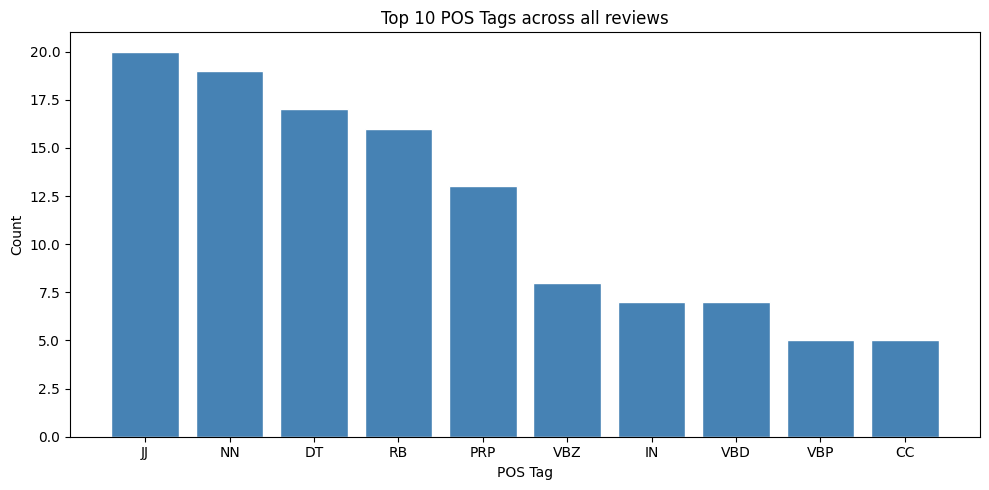

In [4]:
from textblob import TextBlob
from collections import Counter
import matplotlib.pyplot as plt

# Example sentence
blob = TextBlob("TextBlob makes NLP easy and fun.")
print("POS tags:", blob.tags)

# Count POS tags across all reviews
all_tags = []
for text in reviews_text:
    all_tags.extend([tag for _, tag in TextBlob(text).tags])

tag_counts = Counter(all_tags).most_common(10)
tags, counts = zip(*tag_counts)

plt.figure(figsize=(10, 5))
plt.bar(tags, counts, color='steelblue', edgecolor='white')
plt.title('Top 10 POS Tags across all reviews')
plt.xlabel('POS Tag')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


## Section 4 — Tokenization
`blob.words` splits text into individual word tokens.  
`blob.sentences` splits the text into sentence objects.  
We also plot the **word count per review** to spot length differences between sentiment classes.

Words:     ['Hello', 'world', 'TextBlob', 'is', 'cool', 'It', 'splits', 'sentences', 'well']
Sentences: [Sentence("Hello world."), Sentence("TextBlob is cool."), Sentence("It splits sentences well.")]


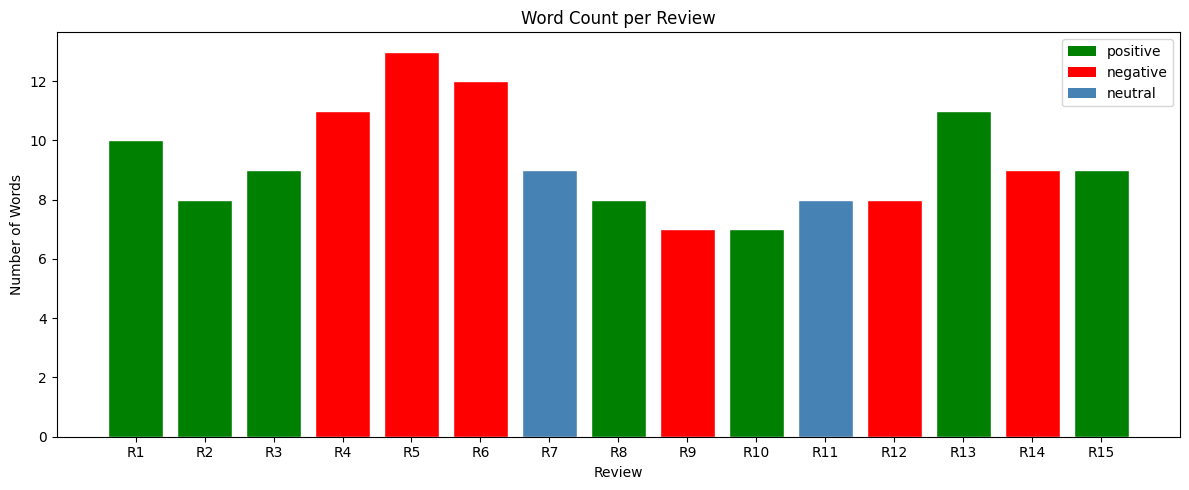

In [5]:
from textblob import TextBlob
import matplotlib.pyplot as plt

# Example
blob = TextBlob("Hello world. TextBlob is cool. It splits sentences well.")
print("Words:    ", blob.words)
print("Sentences:", blob.sentences)

# Word count per review
word_counts = [len(TextBlob(t).words) for t in reviews_text]

colors_map = {'positive': 'green', 'negative': 'red', 'neutral': 'steelblue'}
bar_colors = [colors_map[l] for l in labels]

plt.figure(figsize=(12, 5))
bars = plt.bar(range(len(reviews_text)), word_counts, color=bar_colors, edgecolor='white')
plt.xticks(range(len(reviews_text)), [f'R{i+1}' for i in range(len(reviews_text))])
plt.title('Word Count per Review')
plt.xlabel('Review')
plt.ylabel('Number of Words')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green',    label='positive'),
                   Patch(facecolor='red',      label='negative'),
                   Patch(facecolor='steelblue',label='neutral')]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()


## Section 5 — Lemmatization
Lemmatization reduces inflected word forms to their **base lemma**:
*running → run*, *mice → mouse*, *cats → cat*.  
This is essential before frequency analysis so that *product* and *products* count as one word.

In [6]:
from textblob import TextBlob
from textblob.wordnet import VERB

examples = [
    ("running", VERB),
    ("mice",    None),
    ("cats",    None),
    ("better",  None),
    ("bought",  VERB),
]

print(f"{'Original':<15} {'Lemma':<15}")
print("-" * 30)
for word, pos in examples:
    w     = TextBlob(word).words[0]
    lemma = w.lemmatize(pos) if pos else w.lemmatize()
    print(f"{word:<15} {lemma:<15}")

print()
print(f"Plural of 'cat':   {TextBlob('cat').words[0].pluralize()}")


Original        Lemma          
------------------------------
running         run            
mice            mouse          
cats            cat            
better          better         
bought          buy            

Plural of 'cat':   cats


## Section 6 — Sentiment Analysis (per review)
`blob.sentiment` returns two scores:
- **polarity** ∈ [-1, 1] : negative ↔ positive
- **subjectivity** ∈ [0, 1] : objective ↔ subjective

We classify polarity > 0.1 as *positive*, < -0.1 as *negative*, else *neutral*.

In [7]:
from textblob import TextBlob

polarity_scores    = []
subjectivity_scores= []
predicted_labels   = []

print(f"{'Review':<70} | {'Label':<10} | {'Polarity':>9} | {'TextBlob'}")
print("-" * 115)

for text, label in reviews_with_sentiment:
    blob = TextBlob(text)
    pol  = blob.sentiment.polarity
    sub  = blob.sentiment.subjectivity
    polarity_scores.append(pol)
    subjectivity_scores.append(sub)

    if pol > 0.1:   pred = "positive"
    elif pol < -0.1: pred = "negative"
    else:            pred = "neutral"
    predicted_labels.append(pred)

    match = "✅" if pred == label else "❌"
    print(f"{text:<70} | {label:<10} | {pol:>9.2f} | {pred} {match}")

correct = sum(p == l for p, l in zip(predicted_labels, labels))
print(f"\nAccuracy: {correct}/{len(labels)} = {correct/len(labels):.0%}")


Review                                                                 | Label      |  Polarity | TextBlob
-------------------------------------------------------------------------------------------------------------------
This product is absolutely amazing! I love it so much.                 | positive   |      0.48 | positive ✅
The features are fantastic and it works perfectly.                     | positive   |      0.70 | positive ✅
I am extremely happy with this purchase. Highly recommended!           | positive   |      0.50 | positive ✅
What a terrible experience. The product broke after just one use.      | negative   |     -1.00 | negative ✅
This is the worst item I have ever bought. Complete waste of money.    | negative   |     -0.37 | negative ✅
I was so disappointed. It didn't meet my expectations at all.          | negative   |     -0.75 | negative ✅
It's okay, but nothing special. Could be better.                       | neutral    |      0.45 | positive ❌
Good value for

## Section 7 — Sentiment Distribution Chart
We compare the **provided labels** vs **TextBlob's predictions** side by side.

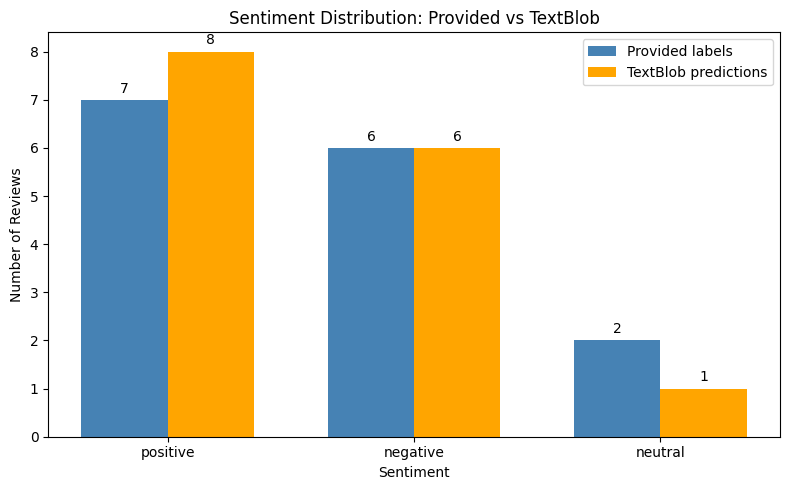

In [8]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

categories = ['positive', 'negative', 'neutral']
provided_counts  = [labels.count(c)           for c in categories]
predicted_counts = [predicted_labels.count(c) for c in categories]

x     = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, provided_counts,  width, label='Provided labels', color='steelblue')
bars2 = ax.bar(x + width/2, predicted_counts, width, label='TextBlob predictions', color='orange')

ax.set_title('Sentiment Distribution: Provided vs TextBlob')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Number of Reviews')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.bar_label(bars1, padding=3)
ax.bar_label(bars2, padding=3)
plt.tight_layout()
plt.show()


## Section 8 — Polarity Score Distribution
A histogram of polarity scores lets us see how the sentiment spreads across the [-1, 1] range.
The dashed lines mark the ±0.1 thresholds used for classification.

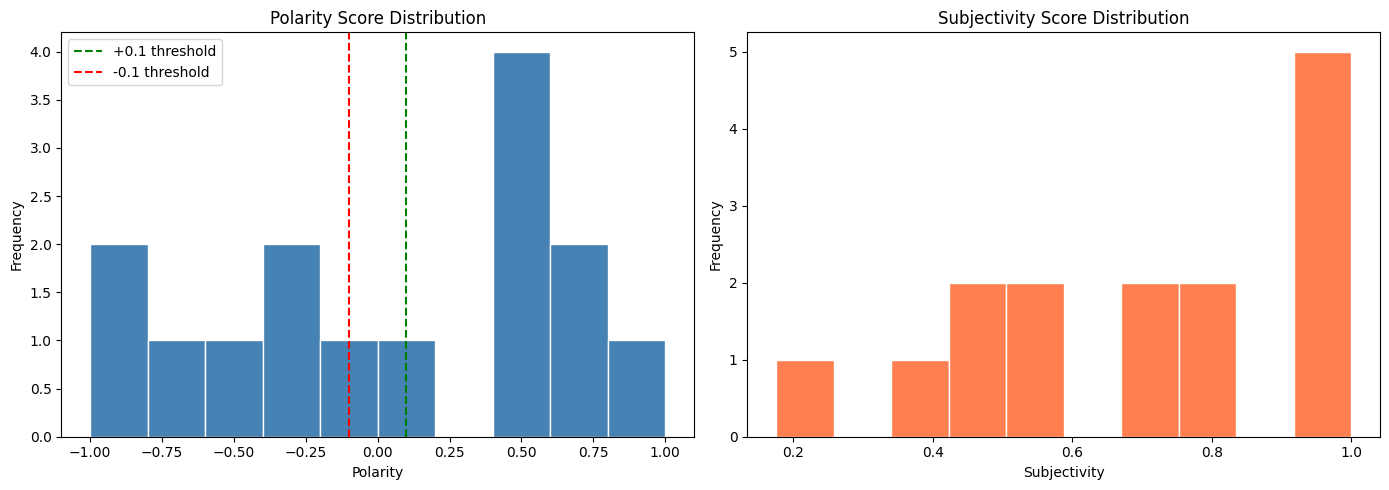

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Polarity histogram
axes[0].hist(polarity_scores, bins=10, color='steelblue', edgecolor='white')
axes[0].axvline( 0.1, color='green', linestyle='--', label='+0.1 threshold')
axes[0].axvline(-0.1, color='red',   linestyle='--', label='-0.1 threshold')
axes[0].set_title('Polarity Score Distribution')
axes[0].set_xlabel('Polarity')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Subjectivity histogram
axes[1].hist(subjectivity_scores, bins=10, color='coral', edgecolor='white')
axes[1].set_title('Subjectivity Score Distribution')
axes[1].set_xlabel('Subjectivity')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


## Section 9 — Word Frequency (post-lemmatization)
We preprocess each review: lowercase → remove punctuation/digits → remove stopwords → lemmatize.
Then we plot the **top 15 most frequent words** to find the dominant vocabulary.

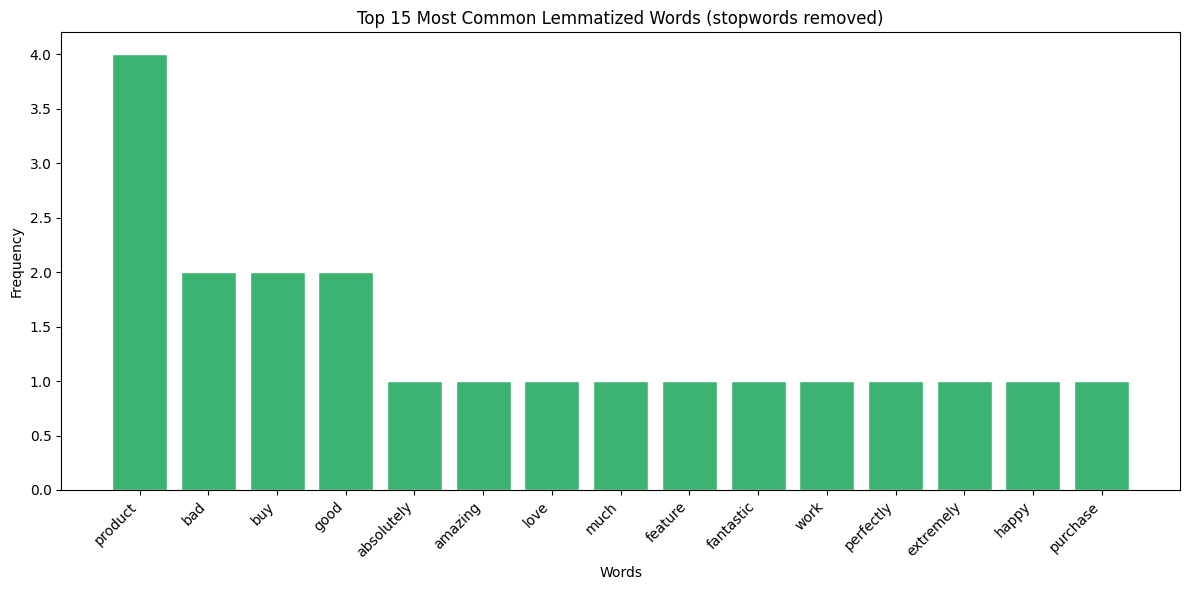

Most common words: [('product', 4), ('bad', 2), ('buy', 2), ('good', 2), ('absolutely', 1), ('amazing', 1), ('love', 1), ('much', 1), ('feature', 1), ('fantastic', 1), ('work', 1), ('perfectly', 1), ('extremely', 1), ('happy', 1), ('purchase', 1)]


In [10]:
from textblob import TextBlob, Word
from collections import Counter
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import re

stop_words           = set(stopwords.words('english'))
all_lemmatized_words = []
full_lemmatized_text = ""

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'): return 'a'
    if treebank_tag.startswith('V'): return 'v'
    if treebank_tag.startswith('N'): return 'n'
    if treebank_tag.startswith('R'): return 'r'
    return 'n'

for review in reviews_text:
    blob  = TextBlob(review.lower())
    lemmatized_words = []
    for word, tag in blob.tags:
        w = re.sub(r'[^\w]', '', str(word))
        w = re.sub(r'\d+', '', w).strip()
        if w and w not in stop_words and len(w) > 1:
            lemma = Word(w).lemmatize(get_wordnet_pos(tag))
            all_lemmatized_words.append(lemma)
            lemmatized_words.append(lemma)
    full_lemmatized_text += " ".join(lemmatized_words) + " "

word_counts       = Counter(all_lemmatized_words)
most_common       = word_counts.most_common(15)
words_plot, cnts  = zip(*most_common)

plt.figure(figsize=(12, 6))
plt.bar(words_plot, cnts, color='mediumseagreen', edgecolor='white')
plt.title('Top 15 Most Common Lemmatized Words (stopwords removed)')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Most common words: {most_common}")


## Section 10 — Word Clouds (Positive vs Negative)
Word clouds give an instant visual summary of the most frequent words.
We generate one for **positive** reviews and one for **negative** reviews
to highlight the vocabulary differences between the two sentiments.

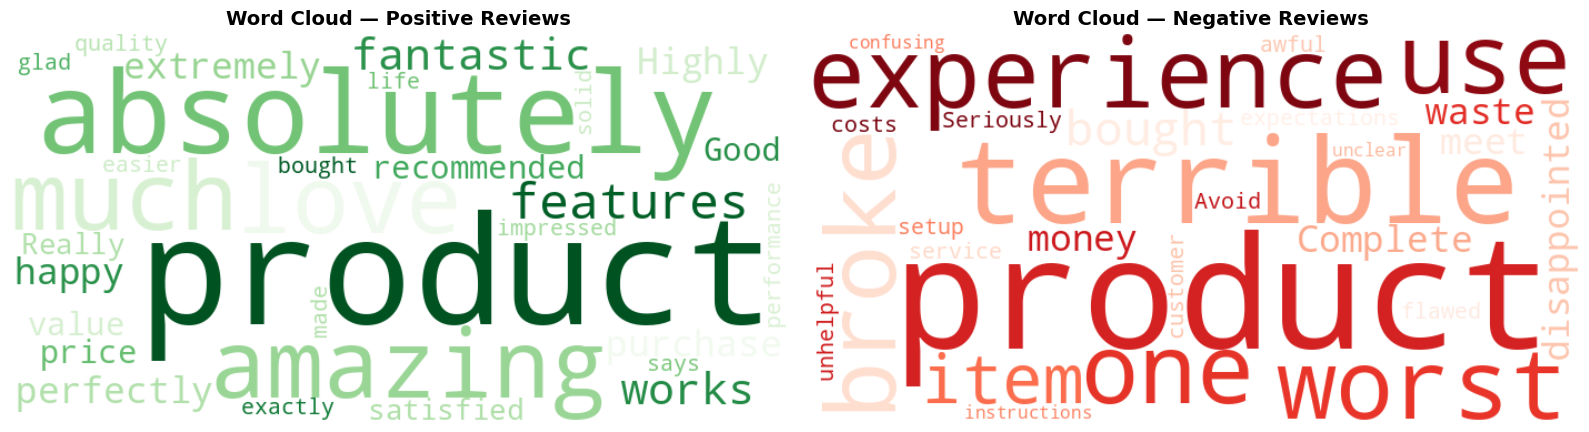

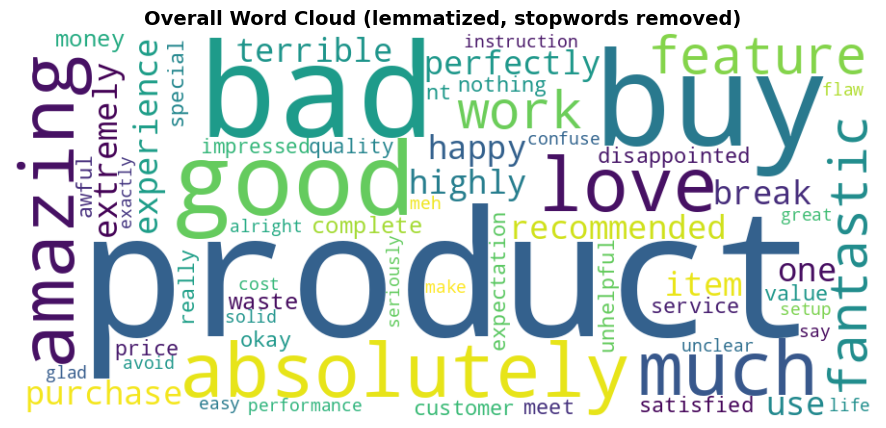

In [11]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_text = " ".join(t for t, l in reviews_with_sentiment if l == "positive")
negative_text = " ".join(t for t, l in reviews_with_sentiment if l == "negative")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, text, title, cmap in [
    (axes[0], positive_text, "Positive Reviews", "Greens"),
    (axes[1], negative_text, "Negative Reviews", "Reds")
]:
    wc = WordCloud(
        width=700, height=350,
        background_color='white',
        colormap=cmap,
        min_font_size=10
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud — {title}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Also: overall word cloud from lemmatized text
wc_all = WordCloud(width=900, height=400, background_color='white').generate(full_lemmatized_text)
plt.figure(figsize=(12, 5))
plt.imshow(wc_all, interpolation='bilinear')
plt.axis('off')
plt.title('Overall Word Cloud (lemmatized, stopwords removed)', fontsize=14, fontweight='bold')
plt.show()


## Section 11 — Subjectivity vs Polarity Scatter Plot
Each review is a point on a 2D plane:
- **X-axis** = polarity (negative ↔ positive)
- **Y-axis** = subjectivity (objective ↔ subjective)

This reveals whether positive/negative reviews tend to be more subjective,
and whether neutral reviews cluster near the center.

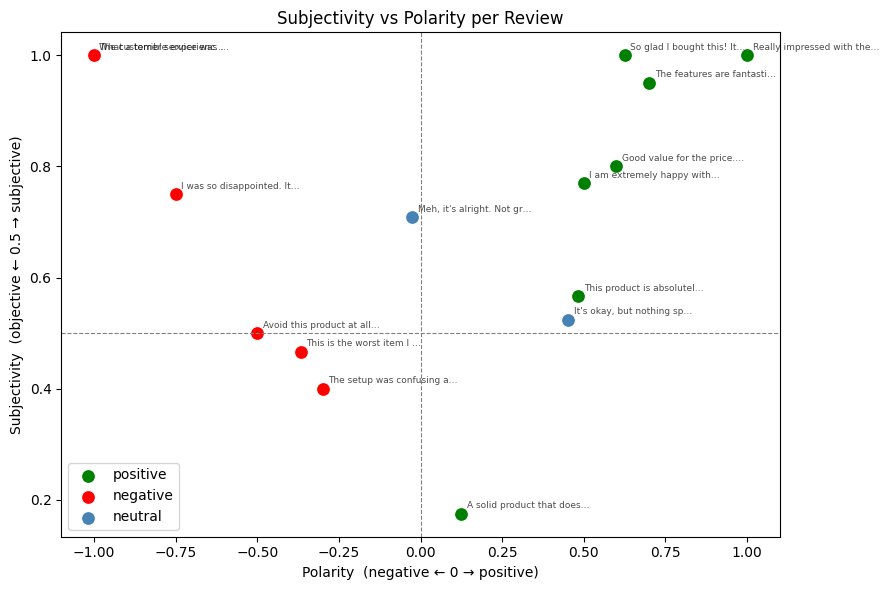

In [12]:
import matplotlib.pyplot as plt

color_map = {'positive': 'green', 'negative': 'red', 'neutral': 'steelblue'}

plt.figure(figsize=(9, 6))

for label_val in ['positive', 'negative', 'neutral']:
    xs = [polarity_scores[i]     for i, l in enumerate(labels) if l == label_val]
    ys = [subjectivity_scores[i] for i, l in enumerate(labels) if l == label_val]
    plt.scatter(xs, ys, c=color_map[label_val], label=label_val, s=100, edgecolors='white', linewidths=0.8)

# Annotate each point with a short review snippet
for i, (pol, sub) in enumerate(zip(polarity_scores, subjectivity_scores)):
    snippet = reviews_text[i][:25] + "…"
    plt.annotate(snippet, (pol, sub), fontsize=6.5, alpha=0.7,
                 xytext=(4, 4), textcoords='offset points')

plt.axvline(0,   color='grey', linestyle='--', linewidth=0.8)
plt.axhline(0.5, color='grey', linestyle='--', linewidth=0.8)
plt.title('Subjectivity vs Polarity per Review')
plt.xlabel('Polarity  (negative ← 0 → positive)')
plt.ylabel('Subjectivity  (objective ← 0.5 → subjective)')
plt.legend()
plt.tight_layout()
plt.show()
